# Trabalho Ciência de Redes
Nome: Rafael Gontijo Ferreira


### Questão 3)

In [95]:
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt


def G(N,p):
    E = []
    V = []
    for i in range(N):
        V.append(i)

        for j in range(i+1, N):
            p_cand = np.random.uniform(0,1)
            if p_cand < p:
                E.append((i, j))
    return V, E



In [96]:
N = 1000 # 5000 meu computador miou :(
mean_k_values = np.array([0.1, 0.2, 0.5, 0.8, 1, 1.5, 2, 4, 8])
prob_values = mean_k_values / (N-1)

Prob: 0.00010, <K>: 0.1, Arestas: 52


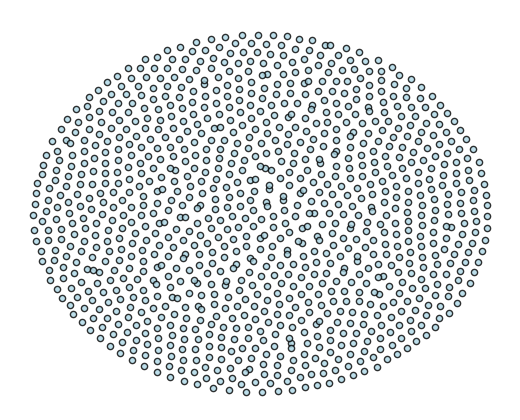

Prob: 0.00020, <K>: 0.2, Arestas: 95


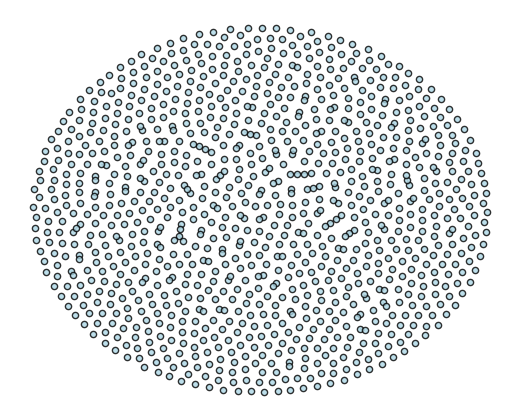

Prob: 0.00050, <K>: 0.5, Arestas: 248


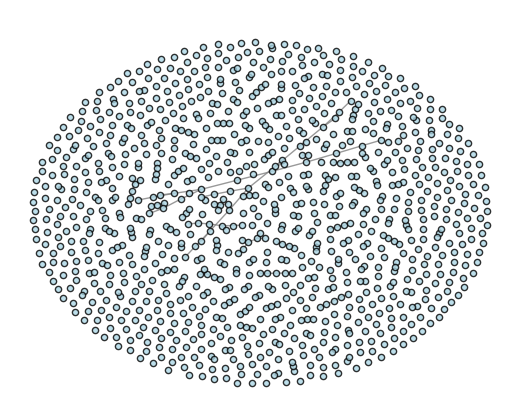

Prob: 0.00080, <K>: 0.8, Arestas: 395


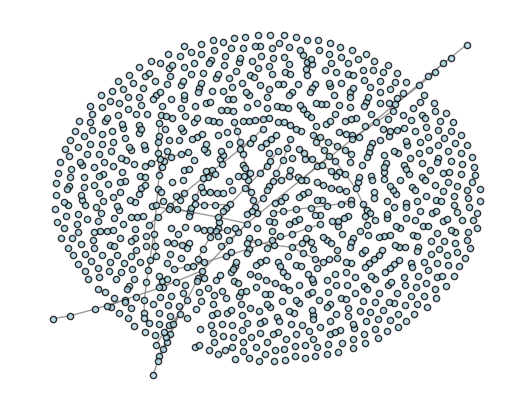

Prob: 0.00100, <K>: 1.0, Arestas: 511


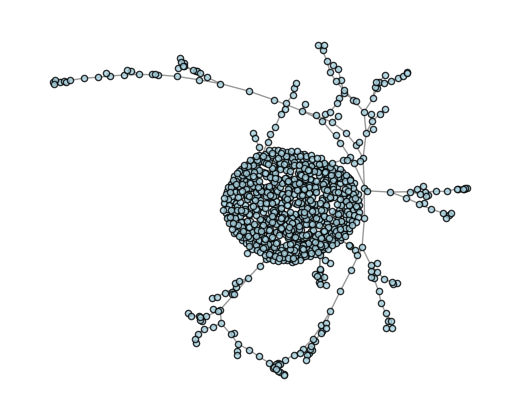

Prob: 0.00150, <K>: 1.5, Arestas: 783


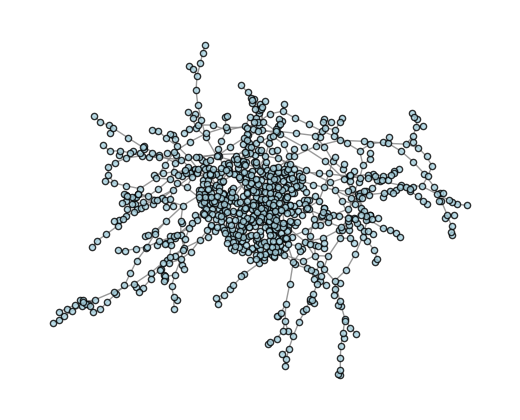

Prob: 0.00200, <K>: 2.0, Arestas: 1040


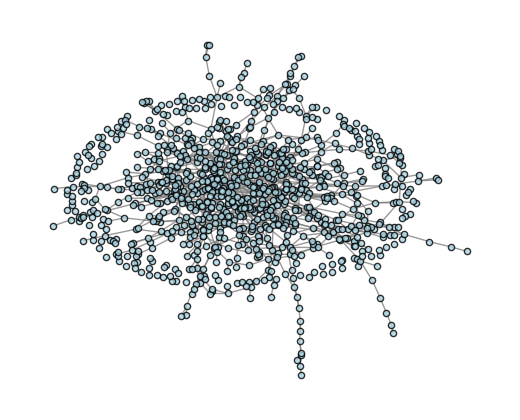

Prob: 0.00400, <K>: 4.0, Arestas: 1988


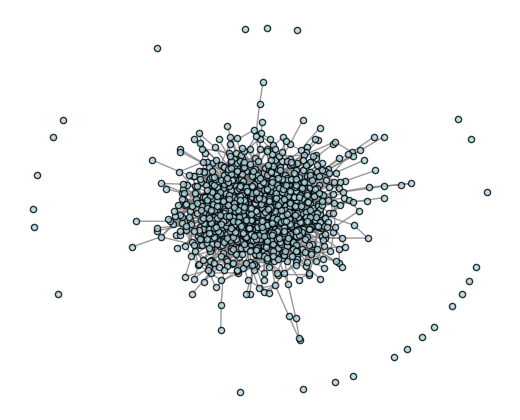

Prob: 0.00801, <K>: 8.0, Arestas: 3939


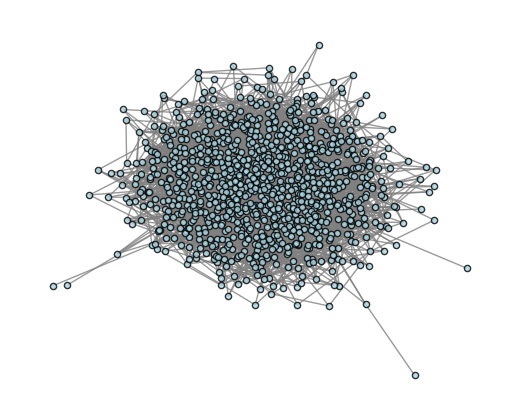

In [97]:
# a)

for prob, m_k in zip(prob_values, mean_k_values):

    V, E = G(N, prob)
    G_graph = nx.Graph()

    plt.figure(figsize=(5,4))

    G_graph.add_nodes_from(V)
    G_graph.add_edges_from(E)

    pos = nx.spring_layout(G_graph)
    print(f"Prob: {prob:.5f}, <K>: {m_k}, Arestas: {len(E)}")
    nx.draw(G_graph, pos, node_size=20, node_color="lightblue", edge_color="gray", edgecolors="black", alpha=0.8)

    plt.show()

    

In [98]:
eixo_x_k = []
eixo_y_fracao = []

for prob, m_k in zip(prob_values, mean_k_values):

    V, E = G(N, prob)
    G_graph = nx.Graph()

    G_graph.add_nodes_from(V)
    G_graph.add_edges_from(E)

    componentes = list(nx.connected_components(G_graph))
    tamanho_max_componente = len(max(componentes, key=len))

    eixo_x_k.append(m_k)
    eixo_y_fracao.append(tamanho_max_componente/N)
    print(f"Prob: {prob:.5f}, <K>: {m_k}, Arestas: {len(E)}, Componentes: {len(componentes)}, Tamanho max componentes: {tamanho_max_componente}")



Prob: 0.00010, <K>: 0.1, Arestas: 54, Componentes: 946, Tamanho max componentes: 5
Prob: 0.00020, <K>: 0.2, Arestas: 89, Componentes: 911, Tamanho max componentes: 4
Prob: 0.00050, <K>: 0.5, Arestas: 230, Componentes: 770, Tamanho max componentes: 8
Prob: 0.00080, <K>: 0.8, Arestas: 403, Componentes: 597, Tamanho max componentes: 20
Prob: 0.00100, <K>: 1.0, Arestas: 475, Componentes: 525, Tamanho max componentes: 61
Prob: 0.00150, <K>: 1.5, Arestas: 765, Componentes: 277, Tamanho max componentes: 585
Prob: 0.00200, <K>: 2.0, Arestas: 1009, Componentes: 160, Tamanho max componentes: 804
Prob: 0.00400, <K>: 4.0, Arestas: 2014, Componentes: 25, Tamanho max componentes: 973
Prob: 0.00801, <K>: 8.0, Arestas: 3921, Componentes: 2, Tamanho max componentes: 999


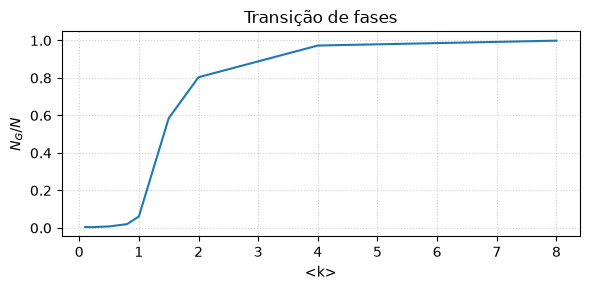

In [99]:
# b)
plt.figure(figsize=(6, 3))

plt.plot(eixo_x_k, eixo_y_fracao)
plt.ylabel(r"$N_G/N$")
plt.xlabel("<k>")
plt.grid(True, linestyle=':', alpha=0.6)
plt.title("Transição de fases")

plt.tight_layout()
plt.show()

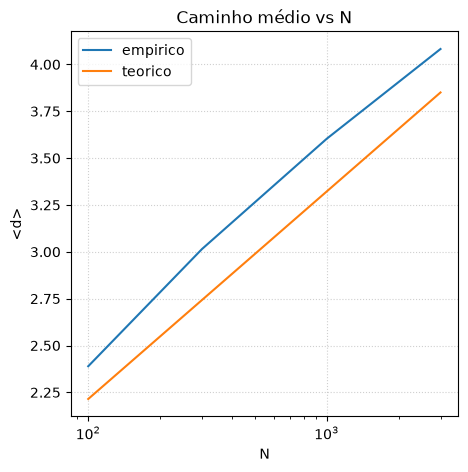

In [100]:
# c)
mean_k = 8
N_values = np.array([100, 300, 1000, 3000]) # 10000 não vai funcionar, meu pc é uma batata

eixo_x_N = []
eixo_y_avg_path_emp = []
eixo_y_avg_path_esp = []

for N_value in N_values:
    eixo_x_N.append(N_value)
    prob = mean_k / (N_value - 1)
    
    V, E = G(N_value, prob)
    G_graph = nx.Graph()
    G_graph.add_nodes_from(V)
    G_graph.add_edges_from(E)

    # se for desconexo não funciona
    maior_comp = max(nx.connected_components(G_graph), key=len)

    G_sub = G_graph.subgraph(maior_comp)

    avg_path = nx.average_shortest_path_length(G_sub)
    eixo_y_avg_path_emp.append(avg_path)

    avg_path_esp = np.log(N_value) / np.log(mean_k)
    eixo_y_avg_path_esp.append(avg_path_esp)

plt.figure(figsize=(5,5))

plt.plot(eixo_x_N, eixo_y_avg_path_emp, label="empirico")
plt.plot(eixo_x_N, eixo_y_avg_path_esp, label="teorico")
plt.xscale("log")
plt.ylabel("<d>")
plt.xlabel("N")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.title("Caminho médio vs N")

plt.show()


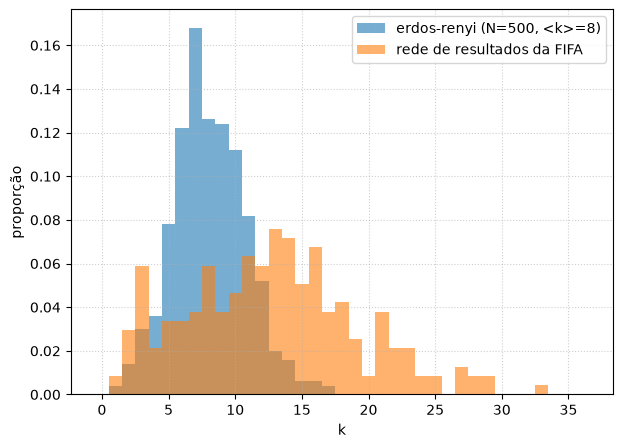

In [108]:
# d)
import pandas as pd

N = 500
mean_k = 8

V, E = G(N, mean_k/N)
G_graph = nx.Graph()
G_graph.add_nodes_from(V)
G_graph.add_edges_from(E)

graus_er = [grau for _, grau in G_graph.degree()]

df_fifa = pd.read_csv("football_edges_filtered.csv")

G_fifa = nx.Graph() 
for _, linha in df_fifa.iterrows():
    G_fifa.add_edge(linha["source"], linha["target"])

graus_fifa = [grau for _, grau in G_fifa.degree()]

plt.figure(figsize=(7, 5))

grau_max = max(max(graus_er), max(graus_fifa))
bins = np.arange(0, grau_max + 5) - 0.5


plt.hist(graus_er, bins=bins, alpha=0.6, density=True, label=f"erdos-renyi (N={N}, <k>={mean_k})")
plt.hist(graus_fifa, bins=bins, alpha=0.6, density=True, label="rede de resultados da FIFA")
plt.xlabel("k")
plt.ylabel("proporção")


plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.xlabel("k")
plt.show()


A rede ER tem grau concentrado perto de <k>=8, quase sem variação (segue uma Poisson). A rede da FIFA tem grau médio maior (12,66) e muito mais espalhado (desvio padrão 6,39, máximo 33), com algumas seleções virando hubs. Isso mostra que o modelo ER não cria hubs.

### Questão 4)

In [124]:
# a)
df_fifa = pd.read_csv("football_edges_filtered.csv")

G_fifa = nx.DiGraph()

for origem, destino, peso in zip(df_fifa["source"], df_fifa["target"], df_fifa["weight"]):
    peso_atual = G_fifa[origem][destino]["weight"] if G_fifa.has_edge(origem, destino) else 0
    G_fifa.add_edge(origem, destino, weight=peso_atual + peso)

print(f"Nós: {G_fifa.number_of_nodes()} | Arestas: {G_fifa.number_of_edges()}")

Nós: 237 | Arestas: 2036


In [125]:
n_nos = G_fifa.number_of_nodes()
n_arestas = G_fifa.number_of_edges()

fracamente_conexa = nx.is_weakly_connected(G_fifa)
fortemente_conexa = nx.is_strongly_connected(G_fifa)
n_comp_fraco = nx.number_weakly_connected_components(G_fifa)
n_comp_forte = nx.number_strongly_connected_components(G_fifa)

indegree_simples = dict(G_fifa.in_degree())
top10_indegree = sorted(indegree_simples.items(), key=lambda x: -x[1])[:10]

print(f"Número de seleções (nós): {n_nos}")
print(f"Número de confrontos distintos (arestas): {n_arestas}")
print(f"Rede fracamente conexa? {fracamente_conexa}  (n de componentes fracos: {n_comp_fraco})")
print(f"Rede fortemente conexa? {fortemente_conexa}  (n de componentes fortes: {n_comp_forte})")
print("Rank:")
for pais, grau in top10_indegree:
    print(f"  {pais}: {grau}")

Número de seleções (nós): 237
Número de confrontos distintos (arestas): 2036
Rede fracamente conexa? False  (n de componentes fracos: 4)
Rede fortemente conexa? False  (n de componentes fortes: 26)
Rank:
  Morocco: 32
  Canada: 25
  Mexico: 24
  England: 23
  Algeria: 23
  Egypt: 23
  Spain: 22
  Argentina: 22
  Nigeria: 21
  France: 20


In [ ]:
# b)

eigenvector = nx.eigenvector_centrality(G_fifa, weight="weight", max_iter=1000)
pagerank = nx.pagerank(G_fifa, weight="weight")


A = nx.to_numpy_array(G_fifa, weight="weight")
lambda_max = max(abs(np.linalg.eigvals(A)))
alpha_katz = 0.99 / lambda_max 
katz = nx.katz_centrality(G_fifa, alpha=alpha_katz, beta=1.0, weight="weight", max_iter=2000)


def top10(dicionario):
    return [pais for pais, _ in sorted(dicionario.items(), key=lambda x: -x[1])[:10]]

print("Autovetor:", top10(eigenvector))
print("Pagerank:", top10(pagerank))
print("Katz:", top10(katz))

Autovetor: ['Spain', 'Argentina', 'Brazil', 'Paraguay', 'Ecuador', 'Colombia', 'France', 'Uruguay', 'Mexico', 'Japan']
Pagerank: ['Spain', 'Argentina', 'France', 'England', 'Portugal', 'Netherlands', 'Colombia', 'Paraguay', 'Brazil', 'Ecuador']
Katz: ['Spain', 'Argentina', 'Brazil', 'Paraguay', 'Ecuador', 'Colombia', 'France', 'Uruguay', 'Mexico', 'England']


As três concordam no topo (Espanha, Argentina, França). Elas divergem um pouco mais abaixo: eigenvector/Katz favorecem times sul-americanos que jogam muito entre si; PageRank favorece mais times europeus. A diferença é que PageRank normaliza pelo total de jogos de quem perdeu, os outros dois não.

In [127]:
# c) 
hubs, autoridades = nx.hits(G_fifa, max_iter=1000)

print("Hubs:", top10(hubs))
print("Autoridades:", top10(autoridades))

Hubs: ['Saudi Arabia', 'Chile', 'Iraq', 'Georgia', 'Belgium', 'Switzerland', 'Peru', 'Serbia', 'Israel', 'Uruguay']
Autoridades: ['Spain', 'England', 'Argentina', 'France', 'Norway', 'Morocco', 'Portugal', 'Turkey', 'Netherlands', 'Italy']


Autoridade do HITS repete o topo do PageRank (Espanha, Inglaterra, Argentina). Hub é bem diferente (Arábia Saudita, Chile, Iraque), são times que perdem bastante, mas para times fortes. Então a distinção hub/autoridade não desaparece totalmente, mas também não traz uma informação nova, hub aqui é quase um "parceiro de competição p/ elite".

In [ ]:
# d)

pais_alvo = "Brazil"
personalizacao_pais = {no: 0.0 for no in G_fifa.nodes()}
personalizacao_pais[pais_alvo] = 1.0

pagerank_brasil = nx.pagerank(G_fifa, weight="weight", personalization=personalizacao_pais)


print("Pagerank Brasil: ", top10(pagerank_brasil))

Pagerank Brasil:  ['Brazil', 'Paraguay', 'Argentina', 'Ecuador', 'Spain', 'Colombia', 'Uruguay', 'Bolivia', 'France', 'Japan']


Personalizando no Brasil, sobem rivais próximos (Paraguai, Equador, Bolívia)

In [129]:
conmebol = ["Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Ecuador", "Paraguay", "Peru", "Uruguay", "Venezuela"]
personalizacao_conf = {no: (1 / len(conmebol) if no in conmebol else 0.0) for no in G_fifa.nodes()}
pagerank_conmebol = nx.pagerank(G_fifa, weight="weight", personalization=personalizacao_conf)

print("Pagerank Conmebol: ", top10(pagerank_conmebol))

Pagerank Conmebol:  ['Paraguay', 'Argentina', 'Ecuador', 'Brazil', 'Colombia', 'Uruguay', 'Spain', 'Bolivia', 'Venezuela', 'Peru']


Personalizando na CONMEBOL inteira, o topo vira os próprios membros fortes da confederação. O ranking da CONMEBOL fica mais parecido com o do Brasil do que com o global.

e)
Duas limitações: falta ponderar por recência (jogo de 15 anos atrás pesa igual a um recente) e viés de calendário/placar (muitos amistosos fáceis, sem dado de gols ou mando de campo). Para corrigir a recência, dá pra multiplicar o peso da aresta por um decaimento exponencial baseado em quantos anos se passaram. Isso exigiria a data de cada jogo, que esse CSV não tem.